# <u>MODELADO:</u>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import joblib

In [37]:
df = pd.read_csv('../data/processed/model_cars.csv')

In [38]:
df

,manufacturer,model,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,...,seller_rating_cat,driver_rating_cat,car_age,car_age_clip,mileage_per_year,mpg_mean,engine_power_index,log_price,log_mileage,log_driver_reviews_num
0,Acura,ILX Hybrid 1.5L,2013,47645.0,1,1,1,NaN,4.4,12,...,sin valoración,4-5,11,11,4331.363636,38.5,6.0,9.797849,10.771554,2.564949
1,Acura,ILX Hybrid 1.5L,2013,53422.0,0,1,1,4.3,4.4,12,...,4-5,4-5,11,11,4856.545455,38.5,6.0,9.740969,10.885997,2.564949
2,Acura,ILX Hybrid 1.5L,2013,117598.0,0,1,1,NaN,4.4,12,...,sin valoración,4-5,11,11,10690.727273,38.5,6.0,9.613002,11.675036,2.564949
3,Acura,ILX Hybrid 1.5L,2013,114865.0,1,0,1,3.7,4.4,12,...,3-4,4-5,11,11,10442.272727,38.5,6.0,9.581766,11.651522,2.564949
4,Acura,ILX Hybrid 1.5L,2013,62042.0,0,0,1,2.2,4.4,12,...,2-3,4-5,11,11,5640.181818,38.5,6.0,9.798127,11.035583,2.564949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591093,Volvo,S60 T5,2020,26781.0,1,1,1,5.0,4.9,24,...,4-5,4-5,4,4,6695.250000,28.5,8.0,10.337961,10.195485,3.218876
591094,Volvo,S60 B5 Momentum,2022,22877.0,0,1,0,4.2,4.2,2,...,4-5,4-5,2,2,11438.500000,29.0,8.0,10.457315,10.037931,1.098612
591095,Volvo,S60 T5,2014,92000.0,0,0,1,NaN,4.8,36,...,sin valoración,4-5,10,10,9200.000000,25.5,12.5,9.417273,11.429555,3.610918
591096,Volvo,S60 T5 Platinum,2013,132000.0,1,0,0,4.6,4.7,62,...,4-5,4-5,11,11,12000.000000,24.5,12.5,9.104424,11.790565,4.143135


## <u>1. Separación del dataset</u>

In [39]:
X = df.drop(columns=['price', 'log_price'])
y = df['price']

##### Train + temp (validación+test)

In [40]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

##### Validación y test a partir de temp

In [41]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print('\nDimensiones del dataset:')
print(f'- X para train: {X_train.shape}\n- X para validación: {X_val.shape}\n- X para test: {X_test.shape}')


Dimensiones del dataset:
- X para train: (354658, 25)
- X para validación: (118220, 25)
- X para test: (118220, 25)


## <u> 2. Prueba de modelos </u>

##### Función de entrenamiento y evaluación del modelo. Para evitar duplicar código y facilitar la comparación entre distintos modelos, se define una función que encapsula todo el proceso de:

 - Preprocesado de variables numéricas y categóricas
 - Entrenamiento del modelo de regresión
 - Evaluación sobre el conjunto de validación

##### La función recibe como argumento la lista de variables numéricas, lo que permite comparar fácilmente diferentes representaciones de una misma variable (por ejemplo, `mileage` frente a `log_mileage`) manteniendo constante el resto del pipeline.


In [42]:
def train_and_evaluate(
    num_features,
    cat_features,
    X_train, y_train,
    X_val, y_val,
    target_log=False
):
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=0.01
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ]
    )

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    if target_log:
        y_pred = np.exp(y_pred)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return mae, rmse, model


### <u>2.1 MODELO con mileage vs MODELO con log_mileage</u>

#### MODELO A **(con mileage)**:

##### Definición de variables:

In [43]:
num_features_mileage = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'
]

cat_features = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat',
    'driver_rating_cat'
]

num_features_log_mileage = num_features_mileage.copy()

num_features_log_mileage[num_features_log_mileage.index('mileage')] = 'log_mileage'


##### Train + Validación: 

In [44]:
mae_mileage, rmse_mileage, _ = train_and_evaluate(
    num_features_mileage,
    cat_features,
    X_train, y_train,
    X_val, y_val
)

print("\nModelo con mileage:")
print(f"MAE: {mae_mileage:.2f}")
print(f"RMSE: {rmse_mileage:.2f}")


Modelo con mileage:
MAE: 6398.01
RMSE: 10394.73


#### MODELO B **(con log_mileage)**:

##### Definición de variables:

In [45]:
num_features_log_mileage = [
    'car_age',
    'log_mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'
]

cat_features = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat',
    'driver_rating_cat'
]

##### Train + Validación:

In [46]:
mae_log, rmse_log, _ = train_and_evaluate(
    num_features_log_mileage,
    cat_features,
    X_train, y_train,
    X_val, y_val
)

print("\nModelo con log_mileage:")
print(f"MAE: {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")


Modelo con log_mileage:
MAE: 6427.72
RMSE: 10439.70


##### Comparación final:

In [47]:
results = pd.DataFrame({
    'Modelo': ['Mileage', 'Log mileage'],
    'MAE': [mae_mileage, mae_log],
    'RMSE': [rmse_mileage, rmse_log]
})

results

,Modelo,MAE,RMSE
0,Mileage,6398.009065,10394.730766
1,Log mileage,6427.718166,10439.700861


##### Conclusión de la comparación mileage vs log_mileage:
##### Se entrenaron dos modelos idénticos, variando únicamente la forma de representar el kilometraje del vehículo. Los resultados muestran que el uso del kilometraje original (`mileage`) obtiene ligeramente mejores valores de MAE y RMSE que la transformación logarítmica (`log_mileage`). Por tanto, en este caso, la transformación logarítmica no mejora el rendimiento predictivo del modelo y se opta por mantener la variable `mileage` en su forma original para los siguientes experimentos.


### <u>2.2 MODELO con driver_rating vs MODELO con driver_rating_cat</u>

#### MODELO A **(con driver_rating)**:

In [48]:
num_features_driver_rating = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num',
    'driver_rating'        
]

cat_features_driver_rating = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat'
]


##### Train + Validación

In [49]:
mae_driver_rating, rmse_driver_rating, model_driver_rating = train_and_evaluate(
    num_features_driver_rating,
    cat_features_driver_rating,
    X_train, y_train,
    X_val, y_val,
    target_log=False
)

print("\nModelo con driver_rating (numérico):")
print(f"MAE: {mae_driver_rating:.2f}")
print(f"RMSE: {rmse_driver_rating:.2f}")


Modelo con driver_rating (numérico):
MAE: 6587.00
RMSE: 10768.36


#### MODELO B **(con driver_rating_cat)**:

In [50]:
num_features_driver_rating_cat = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'
]

cat_features_driver_rating_cat = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat',
    'driver_rating_cat'   
]


##### Train + Validación

In [51]:
mae_driver_rating_cat, rmse_driver_rating_cat, model_driver_rating_cat = train_and_evaluate(
    num_features_driver_rating_cat,
    cat_features_driver_rating_cat,
    X_train, y_train,
    X_val, y_val,
    target_log=False
)

print("\nModelo con driver_rating_cat (categórico)")
print(f"MAE: {mae_driver_rating_cat:.2f}")
print(f"RMSE: {rmse_driver_rating_cat:.2f}")


Modelo con driver_rating_cat (categórico)
MAE: 6398.01
RMSE: 10394.73


##### Comparación

In [52]:
results = pd.DataFrame({
    'Modelo': ['driver_rating', 'driver_rating_cat'],
    'MAE': [mae_driver_rating, mae_driver_rating_cat],
    'RMSE': [rmse_driver_rating, rmse_driver_rating_cat]
})

results

,Modelo,MAE,RMSE
0,driver_rating,6586.997758,10768.363439
1,driver_rating_cat,6398.009065,10394.730766


##### Conclusión de la comparación driver_rating vs driver_rating_cat:

##### Se entrenaron dos modelos idénticos, variando únicamente la forma de representar la valoración del conductor. En el primer caso, se utilizó la variable driver_rating como numérica continua, mientras que en el segundo se empleó la variable driver_rating_cat, que agrupa la valoración en rangos. Los resultados muestran que el modelo que utiliza driver_rating_cat obtiene menores valores de MAE y RMSE. Por tanto, la representación categórica por rangos captura mejor la información relevante de la valoración del conductor y se decide mantener driver_rating_cat para los siguientes experimentos.

### <u>2.3 MODELO con seller_rating vs MODELO con seller_rating_cat</u>

#### MODELO A **(con seller_rating)**:

In [53]:
num_features_seller_rating = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num',
    'seller_rating'       
]

cat_features_seller_rating = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'driver_rating_cat'
]


##### Train + Validación

In [54]:
mae_seller_rating, rmse_seller_rating, model_seller_rating = train_and_evaluate(
    num_features_seller_rating,
    cat_features_seller_rating,
    X_train, y_train,
    X_val, y_val,
    target_log=False
)

print("\nModelo con seller_rating (numérico)")
print(f"MAE: {mae_seller_rating:.2f}")
print(f"RMSE: {rmse_seller_rating:.2f}")


Modelo con seller_rating (numérico)
MAE: 6398.83
RMSE: 10396.04


#### MODELO B **(con seller_rating_cat)**:

In [55]:
num_features_seller_rating_cat = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'      
]

cat_features_seller_rating_cat = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'driver_rating_cat',
    'seller_rating_cat'
]


##### Train + Validación

In [56]:
mae_seller_rating_cat, rmse_seller_rating_cat, model_seller_rating_cat = train_and_evaluate(
    num_features_seller_rating_cat,
    cat_features_seller_rating_cat,
    X_train, y_train,
    X_val, y_val,
    target_log=False
)

print("\nModelo con seller_rating_cat (categórico)")
print(f"MAE: {mae_seller_rating_cat:.2f}")
print(f"RMSE: {rmse_seller_rating_cat:.2f}")


Modelo con seller_rating_cat (categórico)
MAE: 6398.01
RMSE: 10394.73


##### Comparación

In [57]:
results = pd.DataFrame({
    'Modelo': ['seller_rating', 'seller_rating_cat'],
    'MAE': [mae_seller_rating, mae_seller_rating_cat],
    'RMSE': [rmse_seller_rating, rmse_seller_rating_cat]
})

results

,Modelo,MAE,RMSE
0,seller_rating,6398.831906,10396.043909
1,seller_rating_cat,6398.009065,10394.730766


##### Conclusión de la comparación seller_rating vs seller_rating_cat:
##### Se entrenaron dos modelos idénticos, variando únicamente la forma de representar la valoración del vendedor. En el primer caso, se utilizó la variable seller_rating como numérica continua, mientras que en el segundo se empleó la variable seller_rating_cat, que agrupa la valoración en rangos. Los resultados muestran que ambos modelos nos arrojan los mismos los resultados. Debido a que anteriormente nos quedamos con la categórica, volveremos a quedarnos con la categórica.

### <u>2.4 MODELO con price vs MODELO con log_price</u>

##### Modelo A: target=price (Es el mismo que el Modelo A inicial, con milegae, seller_rating_cat y driver_rating_cat)

##### Modelo B: target = log_price

#### MODELO B **(con log_price)**:

##### Se define el target transformado

In [58]:
y_log = df['log_price']

y_log_train = y_log.loc[X_train.index]
y_log_val   = y_log.loc[X_val.index]
y_log_test  = y_log.loc[X_test.index]

##### Definición de variables:

In [59]:
num_features_log_price = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'
]

cat_features_log_price = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat',
    'driver_rating_cat'
]

##### Train + Validación:

In [60]:
mae_logprice, rmse_logprice, model_log_price = train_and_evaluate(
    num_features_log_price,
    cat_features_log_price,
    X_train, y_log_train,   
    X_val, y_val,           
    target_log=True
)

print("Modelo con log_price (evaluado en €)")
print(f"MAE: {mae_logprice:.2f}")
print(f"RMSE: {rmse_logprice:.2f}")

Modelo con log_price (evaluado en €)
MAE: 5294.81
RMSE: 9611.90


##### Comparación 'price' vs 'log-price'

##### Preparación del modelo base (price) para la comparación

##### Alias para claridad semántica. (No hemos hecho el proceso de train + validation con price porque era exactamente lo mismo que con mileage que ya lo teníamos hecho de antes, por tanto, lo reutilizamos).

In [61]:
mae_price = mae_mileage
rmse_price = rmse_mileage

In [62]:
results_target = pd.DataFrame({
    'Target': ['price', 'log_price'],
    'MAE (€)': [mae_price, mae_logprice],
    'RMSE (€)': [rmse_price, rmse_logprice]
})

results_target

,Target,MAE (€),RMSE (€)
0,price,6398.009065,10394.730766
1,log_price,5294.812140,9611.897216


##### La transformación logarítmica del target mejora el rendimiento del modelo, reduciendo tanto el MAE como el RMSE. Por ello, se selecciona log_price como target final del modelo.


### <u>2.5 MODELO BASE:</u>

##### Se evalúa el modelo base seleccionado (log_price, mileage, seller_rating_cat, driver_rating_cat) en el conjunto de validación, con el objetivo de establecer una referencia de rendimiento antes de aplicar técnicas de optimización y modelos más complejos.

In [63]:
precio_medio_val = y_val.mean()
mae_relativo_val = (mae_logprice / precio_medio_val) * 100

print(f"Precio medio (validación): {precio_medio_val:.2f} €")
print(f"MAE relativo (validación): {mae_relativo_val:.2f} %")

Precio medio (validación): 32106.32 €
MAE relativo (validación): 16.49 %


##### Evaluación del modelo base (validación)

##### Para evaluar si el error obtenido por el modelo base es razonable antes de aplicar técnicas de optimización, se calculó el MAE relativo respecto al precio medio de los vehículos en el conjunto de validación. El modelo presenta un MAE relativo del **16,49%**, lo que indica que, de media, el error de predicción supone aproximadamente un 16% del valor real del vehículo.

##### Este resultado sugiere que el modelo base ofrece un rendimiento sólido y coherente, siendo capaz de capturar relaciones relevantes entre las variables explicativas y el precio. Además, el hecho de que las métricas de validación sean similares a las obtenidas posteriormente en test indica una buena capacidad de generalización y ausencia de overfitting significativo. A partir de este punto, se procede a mejorar el modelo mediante el ajuste de hiperparámetros y el uso de modelos más complejos como XGBoost.

## <u> 3. Modelo final </u>

##### Recreamos el preprocesador ya que el anterior está dentro de la función. Definimos el pipeline con XGBOOST y lo unimos con el preprocesador. Luego definimos los hiperparámetros

In [64]:
num_features = [
    'car_age',
    'mileage',
    'mileage_per_year',
    'engine_liters',
    'engine_cylinders',
    'engine_power_index',
    'mpg_mean',
    'driver_reviews_num'
]

cat_features = [
    'manufacturer',
    'model',
    'fuel_simple',
    'transmission_simple',
    'drivetrain_simple',
    'accidents_or_damage',
    'one_owner',
    'personal_use_only',
    'seller_rating_cat',
    'driver_rating_cat'
]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features), 
        ('cat', cat_transformer, cat_features) 
    ]
)

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(random_state=42, n_jobs=-1))
])

param_grid_xgb = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 7, 10],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0]
}


random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=15,                              
    scoring='neg_root_mean_squared_error',  
    cv=3,                                   
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_log_train)

print(f"Mejores parámetros: {random_search_xgb.best_params_}")
print(f"Mejor RMSE (negativo): {random_search_xgb.best_score_}")

best_xgb_pipeline = random_search_xgb.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores parámetros: {'xgb__subsample': 1.0, 'xgb__n_estimators': 500, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
Mejor RMSE (negativo): -0.12262767156317961


##### Usamos el modelo ganador para predecir en Validación, deshacemos el logaritmo (volvemos a precios reales). Calculamos el error comparando con el precio real y comparamos visualmente los primeros 5 coches

In [65]:
y_pred_log = best_xgb_pipeline.predict(X_val)

y_pred_real = np.exp(y_pred_log)

mae = mean_absolute_error(y_val, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_real))

print(f"\n--- RESULTADOS FINALES EN VALIDACIÓN ---")
print(f"MAE (Error Medio Absoluto): {mae:,.2f}€")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:,.2f}€")

print("\n--- Ejemplo: Realidad vs Predicción ---")
for i in range(5):
    real = y_val.iloc[i] if hasattr(y_val, 'iloc') else y_val[i]
    pred = y_pred_real[i]
    diff = pred - real
    print(f"Coche {i+1}: Real={real:,.0f}€ | Predicho={pred:,.0f}€ | Diferencia: {diff:,.0f}€")


--- RESULTADOS FINALES EN VALIDACIÓN ---
MAE (Error Medio Absoluto): 2,552.25€
RMSE (Raíz del Error Cuadrático): 4,393.93€

--- Ejemplo: Realidad vs Predicción ---
Coche 1: Real=16,016€ | Predicho=16,524€ | Diferencia: 508€
Coche 2: Real=15,477€ | Predicho=16,384€ | Diferencia: 907€
Coche 3: Real=44,995€ | Predicho=38,541€ | Diferencia: -6,454€
Coche 4: Real=12,900€ | Predicho=13,998€ | Diferencia: 1,098€
Coche 5: Real=12,585€ | Predicho=13,546€ | Diferencia: 961€


##### Guardamos el pipeline completo (preprocesador + modelo)

In [66]:
nombre_archivo = '../models/mejor_modelo_xgboost.pkl'
joblib.dump(best_xgb_pipeline, nombre_archivo)

print(f"Modelo guardado correctamente como '{nombre_archivo}'")

Modelo guardado correctamente como '../models/mejor_modelo_xgboost.pkl'



📊 --- RESULTADOS DEFINITIVOS (TEST) ---
MAE Final:  2,552.14€
RMSE Final: 4,307.66€
R² Final:    0.9475 (Explica el 94.7% de la varianza)


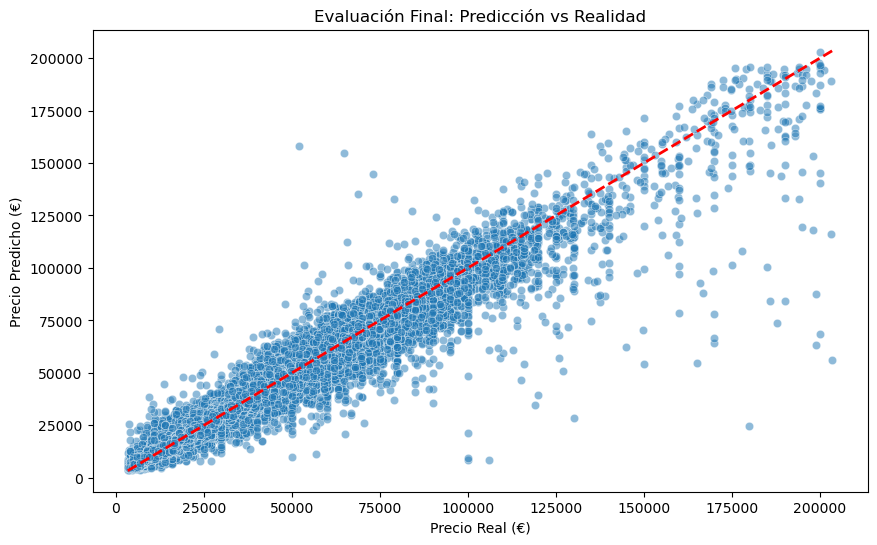

In [67]:
# 1. Predecimos sobre el conjunto de TEST (X_test)
# Recuerda: X_test pasa "crudo", el pipeline se encarga de transformarlo
y_pred_test_log = best_xgb_pipeline.predict(X_test)

# 2. Convertimos las predicciones de Logaritmo a Precio Real ($)
y_pred_test_real = np.exp(y_pred_test_log)

# 3. Preparamos los datos reales para comparar
# ASUMIMOS que 'y_test' contiene los precios reales.
# Si tu variable 'y_test' estuviera en logaritmo, descomenta la siguiente línea:
# y_test_real = np.exp(y_test)
# Si 'y_test' ya son euros/dólares, usa esta:
y_test_real = y_test

# 4. Calculamos las métricas definitivas
mae_test = mean_absolute_error(y_test_real, y_pred_test_real)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
r2_test = r2_score(y_test_real, y_pred_test_real)

print(f"\n📊 --- RESULTADOS DEFINITIVOS (TEST) ---")
print(f"MAE Final:  {mae_test:,.2f}€")
print(f"RMSE Final: {rmse_test:,.2f}€")
print(f"R² Final:    {r2_test:.4f} (Explica el {r2_test*100:.1f}% de la varianza)")

# 5. Gráfico: Realidad vs Predicción
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_pred_test_real, alpha=0.5)
# Línea de perfección (donde predicción == realidad)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.title('Evaluación Final: Predicción vs Realidad')
plt.show()

In [68]:
#y_log_pred_test = model_log_price.predict(X_test)
#y_pred_test_logprice = np.exp(y_log_pred_test)

# mae_test_logprice = mean_absolute_error(y_test, y_pred_test_logprice)
# rmse_test_logprice = np.sqrt(mean_squared_error(y_test, y_pred_test_logprice))

# print("\nEvaluación final en TEST (log_price, mileage, driver_rating_cat y seller_rating_cat)")
# print(f"MAE test: {mae_test_logprice:.2f}")
# print(f"RMSE test: {rmse_test_logprice:.2f}")

In [69]:
# precio_medio_test = y_test.mean()

# mae_relativo = (mae_test_logprice / precio_medio_test) * 100

# print(f"Precio medio (test): {precio_medio_test:.2f} €")
# print(f"MAE relativo: {mae_relativo:.2f} %")